In [1]:
import pandas as pd
from scipy import stats
import numpy as np
%matplotlib inline

In [74]:
filename = 'rawdata_2025-05-13_15-06@50Hz_1800mV.csv'
data = pd.read_csv(filename, index_col=0)
data.describe()

,time,ch_A,ch_B
count,5.000000e+05,500000.000000,500000.000000
mean,2.499995e+08,61.308424,4.408562
std,1.443377e+08,1237.371751,1058.995169
min,0.000000e+00,-2914.769931,-1677.595965
25%,1.249998e+08,-353.254183,-978.592520
50%,2.499995e+08,44.137549,0.000000
75%,3.749992e+08,485.666831,978.592520
max,4.999990e+08,3003.045030,1695.066437


In [75]:
data.loc[10001].ch_A = -3100
data.loc[20001].ch_A = 3200

In [83]:
data.ch_A.abs().max()

np.float64(3003.045029527559)

<Axes: xlabel='time'>

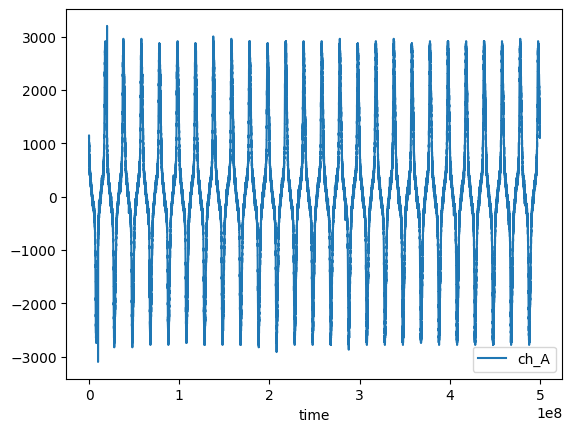

In [69]:
df.plot(x='time', y=['ch_A'])

In [ ]:
data.loc[data.ch_A >= 3100] = np.nan
data.loc[data.ch_A <= -3100] = np.nan

,time,ch_A,ch_B
0,0.0,1104.053888,-297.059547
1,1000.0,1148.191437,-297.059547
2,2000.0,1104.053888,-297.059547
3,3000.0,1148.191437,-297.059547
4,4000.0,1104.053888,-297.059547
...,...,...,...
499995,499995000.0,1148.191437,-297.059547
499996,499996000.0,1148.191437,-297.059547
499997,499997000.0,1148.191437,-262.118602
499998,499998000.0,1148.191437,-279.589075


In [91]:
data = data.interpolate()

In [92]:
data[data.ch_A.isnull()]

,time,ch_A,ch_B


In [49]:
print(f'Наличине выбросов A - {df.ch_A.isnull().sum()}')
# print(f'Наличине выбросов B - {df.ch_B.isnull().sum()}')

Наличине выбросов A - 2


In [15]:
# Убираем выбросы - простой вариант
def remove_outliers(series, threshold=3):
    median = series.median()
    mad = (series - median).abs().median()
    modified_z_score = 0.6745 * (series - median) / mad
    return series[modified_z_score < threshold]

df['ch_A'] = remove_outliers(df['ch_A'])
# df = df.interpolate()

In [78]:
df.loc[10002].ch_A

np.float64(-70.52780511811024)

<Axes: xlabel='time'>

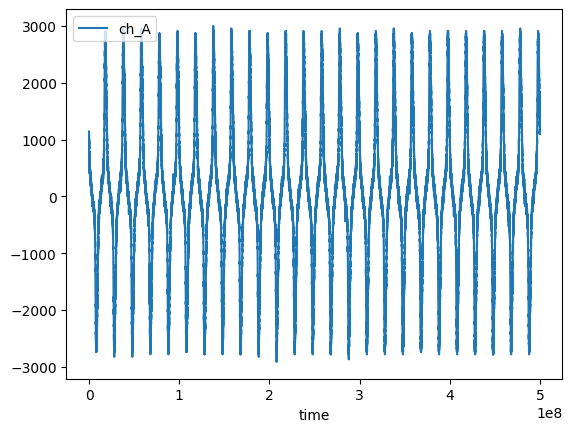

In [50]:
df.plot(x='time', y=['ch_A'])